# Zonal Skill Profiles : East Africa MAM 2024

How does forecast skill degrade by **latitude**? For each model we collapse the
domain into a 1-D profile: a metric computed per latitude row, averaged over all
longitudes and forecast cases.

- **Models:** FourCastNet (deterministic), GenCast (10-member ensemble), GraphCast (deterministic)
- **Truth:** CHIRPS
- **Metrics:** CRPS, Bias, MAE, RMSE  (CRPS reduces to MAE for the 1-member models)

Start simple (lead day 1, CHIRPS only); we improve the plots afterwards.

In [9]:
import os, sys, glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('.'))
from benchmark_ea.config import BenchmarkConfig
from benchmark_ea.truth import chirps as chirps_io

MODELS       = ['fourcastnet', 'gencast', 'graphcast']
COLORS       = {'fourcastnet': '#d4a017', 'gencast': '#2196F3', 'graphcast': '#E53935'}
MODEL_LABELS = {'fourcastnet': 'FourCastNet', 'gencast': 'GenCast', 'graphcast': 'GraphCast'}

START, END = '2024-03-01', '2024-05-31'   # init dates (MAM)
OBS_END    = '2024-06-10'                  # cover init END + max lead day
INIT_DATES = pd.date_range(START, END, freq='D')

In [10]:
# ── Load predictions (concat scattered init-date zarrs) ───────────────────────
preds = {}
for m in MODELS:
    files = sorted(glob.glob(f'data/predictions/{m}/pred_2024-*.zarr'))
    preds[m] = xr.concat([xr.open_zarr(f)['total_precipitation'] for f in files], dim='init_time')
    print(f'{m:12s} {dict(preds[m].sizes)}')

# ── Load CHIRPS truth → {date: (lat, lon)} lookup ─────────────────────────────
cfg = BenchmarkConfig()
chirps_da = chirps_io.load(START, OBS_END, cfg.lat_vals, cfg.lon_vals,
                           cfg.chirps_cache_dir, download_missing=False)
obs_2d = {pd.Timestamp(t).date(): chirps_da.sel(time=t).values for t in chirps_da.time.values}
LAT = preds['gencast'].lat.values
print(f'CHIRPS {dict(chirps_da.sizes)} | {len(obs_2d)} days')

fourcastnet  {'init_time': 359, 'sample': 1, 'lead_day': 4, 'lat': 28, 'lon': 25}
gencast      {'init_time': 175, 'sample': 10, 'lead_day': 4, 'lat': 28, 'lon': 25}
graphcast    {'init_time': 347, 'sample': 1, 'lead_day': 4, 'lat': 28, 'lon': 25}
CHIRPS {'time': 102, 'lat': 28, 'lon': 25} | 102 days


## Zonal profile

For each model / lead day we stack all forecast–observation cases, reduce over
cases, then average over longitude to leave a value per latitude. CRPS uses the
fair-ensemble formula `E|X−y| − ½E|X−X'|`, which equals MAE when there is a single member.

We also attach a **95% bootstrap confidence interval** by resampling the forecast
days (cases) with replacement — this shows whether a latitudinal feature (e.g. a
skill spike) is robust or just sampling noise.

In [21]:
METRICS = ['CRPS', 'Bias', 'MAE', 'RMSE']

def _crps_per_case(fc, obs):
    """fc (case, sample, lat, lon), obs (case, lat, lon) -> CRPS (case, lat, lon)."""
    term1 = np.abs(fc - obs[:, None]).mean(axis=1)
    term2 = 0.5 * np.abs(fc[:, :, None] - fc[:, None, :]).mean(axis=(1, 2))
    return term1 - term2

def _per_lat(metric, err, crps):
    """Reduce per-case (case, lat, lon) fields to one value per latitude."""
    if   metric == 'CRPS': field = np.nanmean(crps, axis=0)
    elif metric == 'Bias': field = np.nanmean(err, axis=0)
    elif metric == 'MAE':  field = np.nanmean(np.abs(err), axis=0)
    else:                  field = np.sqrt(np.nanmean(err ** 2, axis=0))
    return np.nanmean(field, axis=1)                     # average over lon

def zonal_profile(model, lead_day=1, n_boot=100, seed=0):
    """Per-latitude metrics + 95% bootstrap CIs (resampling forecast days)."""
    fc_da = preds[model].sel(lead_day=lead_day)
    fc_list, ob_list = [], []
    for init in INIT_DATES:
        vd = (init + pd.Timedelta(days=lead_day)).date()
        if vd not in obs_2d:
            continue
        try:
            fc = fc_da.sel(init_time=init).values        # (sample, lat, lon)
        except KeyError:
            continue                                     # no forecast for this init
        fc_list.append(fc)
        ob_list.append(obs_2d[vd])
    fc_all = np.stack(fc_list)                           # (case, sample, lat, lon)
    ob_all = np.stack(ob_list)                           # (case, lat, lon)

    err  = fc_all.mean(axis=1) - ob_all                  # ensemble-mean error
    crps = _crps_per_case(fc_all, ob_all)

    point = pd.DataFrame({m: _per_lat(m, err, crps) for m in METRICS},
                         index=pd.Index(LAT, name='lat'))

    # bootstrap over cases
    rng, n = np.random.default_rng(seed), err.shape[0]
    ci = {}
    for m in METRICS:
        boot = np.empty((n_boot, len(LAT)))
        for b in range(n_boot):
            idx = rng.integers(0, n, n)
            boot[b] = _per_lat(m, err[idx], crps[idx])
        ci[m] = np.nanpercentile(boot, [2.5, 97.5], axis=0)   # (2, lat)
    return point, ci

In [17]:
LEAD_DAY = 1
profiles, cis = {}, {}
for m in MODELS:
    profiles[m], cis[m] = zonal_profile(m, LEAD_DAY)
profiles['gencast'].round(3)

,CRPS,Bias,MAE,RMSE
lat,,,,
-12.0,2.501,-0.135,3.166,6.041
-11.0,2.928,0.822,3.774,6.545
-10.0,3.431,-0.266,4.334,7.799
-9.0,5.904,1.887,7.171,14.740
-8.0,3.751,0.455,4.775,8.633
-7.0,2.978,0.269,3.810,7.012
-6.0,3.212,0.339,4.019,7.205
-5.0,3.430,-0.357,4.242,7.932
-4.0,2.905,-0.808,3.656,6.527


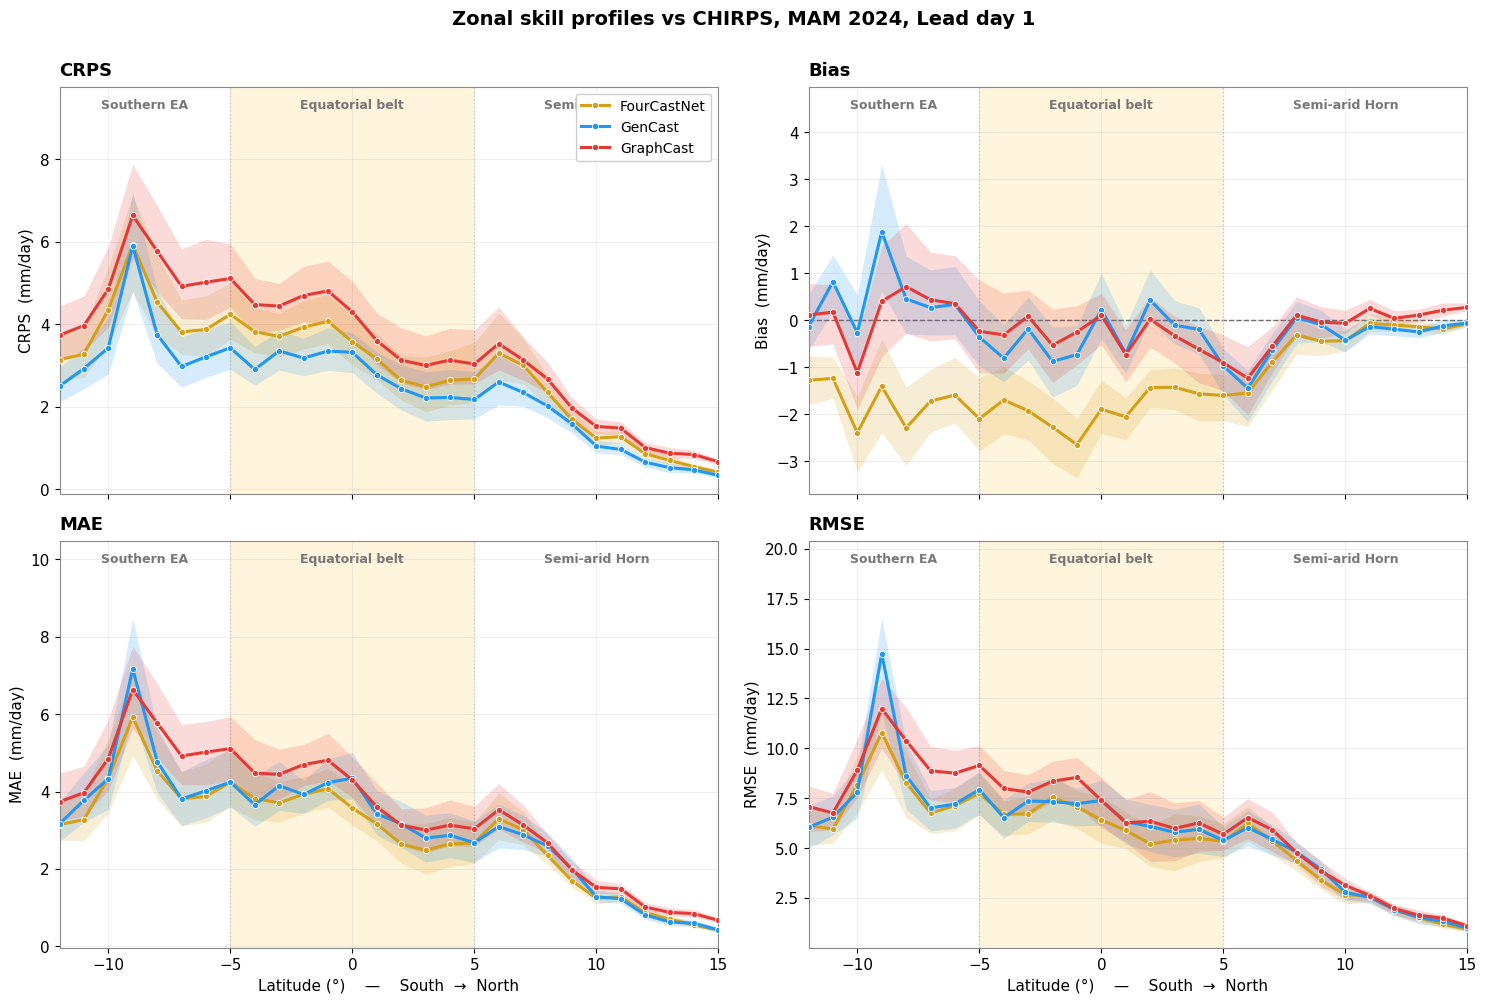

In [24]:
# ── Polished zonal skill profiles (lead day 1) ────────────────────────────────
plt.rcParams.update({'font.size': 11, 'axes.edgecolor': '#888888'})

# Climate zones (lat_lo, lat_hi, label)
ZONES = [(-12, -5, 'Southern EA'),
         (-5,   5, 'Equatorial belt'),
         (5,   15, 'Semi-arid Horn')]

def add_zone_context(ax, label_zones=False):
    """Shade the equatorial band, draw zone boundaries, optionally label zones."""
    ax.axvspan(-5, 5, color='#ffe7b3', alpha=0.45, lw=0, zorder=0)
    for b in (-5, 5):
        ax.axvline(b, color='#cccccc', ls=':', lw=1, zorder=1)
    if label_zones:
        # add headroom so labels clear the data, then place them just inside the top
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax + 0.18 * (ymax - ymin))
        for lo_z, hi_z, name in ZONES:
            ax.text((lo_z + hi_z) / 2, 0.97, name, transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=9, color='#777777', fontweight='bold')

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.ravel()

for ax, metric in zip(axes, METRICS):
    for m in MODELS:
        lo, hi = cis[m][metric]
        ax.fill_between(LAT, lo, hi, color=COLORS[m], alpha=0.18, lw=0, zorder=2)
        ax.plot(LAT, profiles[m][metric].values, color=COLORS[m], lw=2.2,
                marker='o', ms=4.5, mec='white', mew=0.6,
                label=MODEL_LABELS[m], zorder=3)
    if metric == 'Bias':
        ax.axhline(0, color='#333333', ls='--', lw=1, alpha=0.8, zorder=1)
    ax.set_title(metric, fontsize=13, fontweight='bold', loc='left', pad=8)
    ax.set_ylabel(f'{metric}  (mm/day)', fontsize=11)
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_xlim(LAT.min(), LAT.max())
    add_zone_context(ax, label_zones=True)

for ax in axes[2:]:
    ax.set_xlabel('Latitude (°)    —    South  →  North', fontsize=11)

axes[0].legend(fontsize=10, loc='upper right', framealpha=0.95)
fig.suptitle('Zonal skill profiles vs CHIRPS, MAM 2024, Lead day 1',
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('mam2024_analysis_outputs/zonal_skill_profiles.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Skill degradation across lead days

Repeat the zonal profiles for every available lead day (1, 3, 5, 7). The grid
below has one row per metric and one column per lead day (y-scale shared within
each row), so reading **left → right** shows how the latitudinal skill structure
erodes as the forecast horizon lengthens.

In [19]:
# ── Compute profiles for every lead day ───────────────────────────────────────
LEAD_DAYS = [int(x) for x in preds['gencast'].lead_day.values]   # [1, 3, 5, 7]

profiles_ld, cis_ld = {}, {}
for ld in LEAD_DAYS:
    profiles_ld[ld], cis_ld[ld] = {}, {}
    for m in MODELS:
        profiles_ld[ld][m], cis_ld[ld][m] = zonal_profile(m, ld)
    print(f'lead day {ld} done')

lead day 1 done
lead day 3 done
lead day 5 done
lead day 7 done


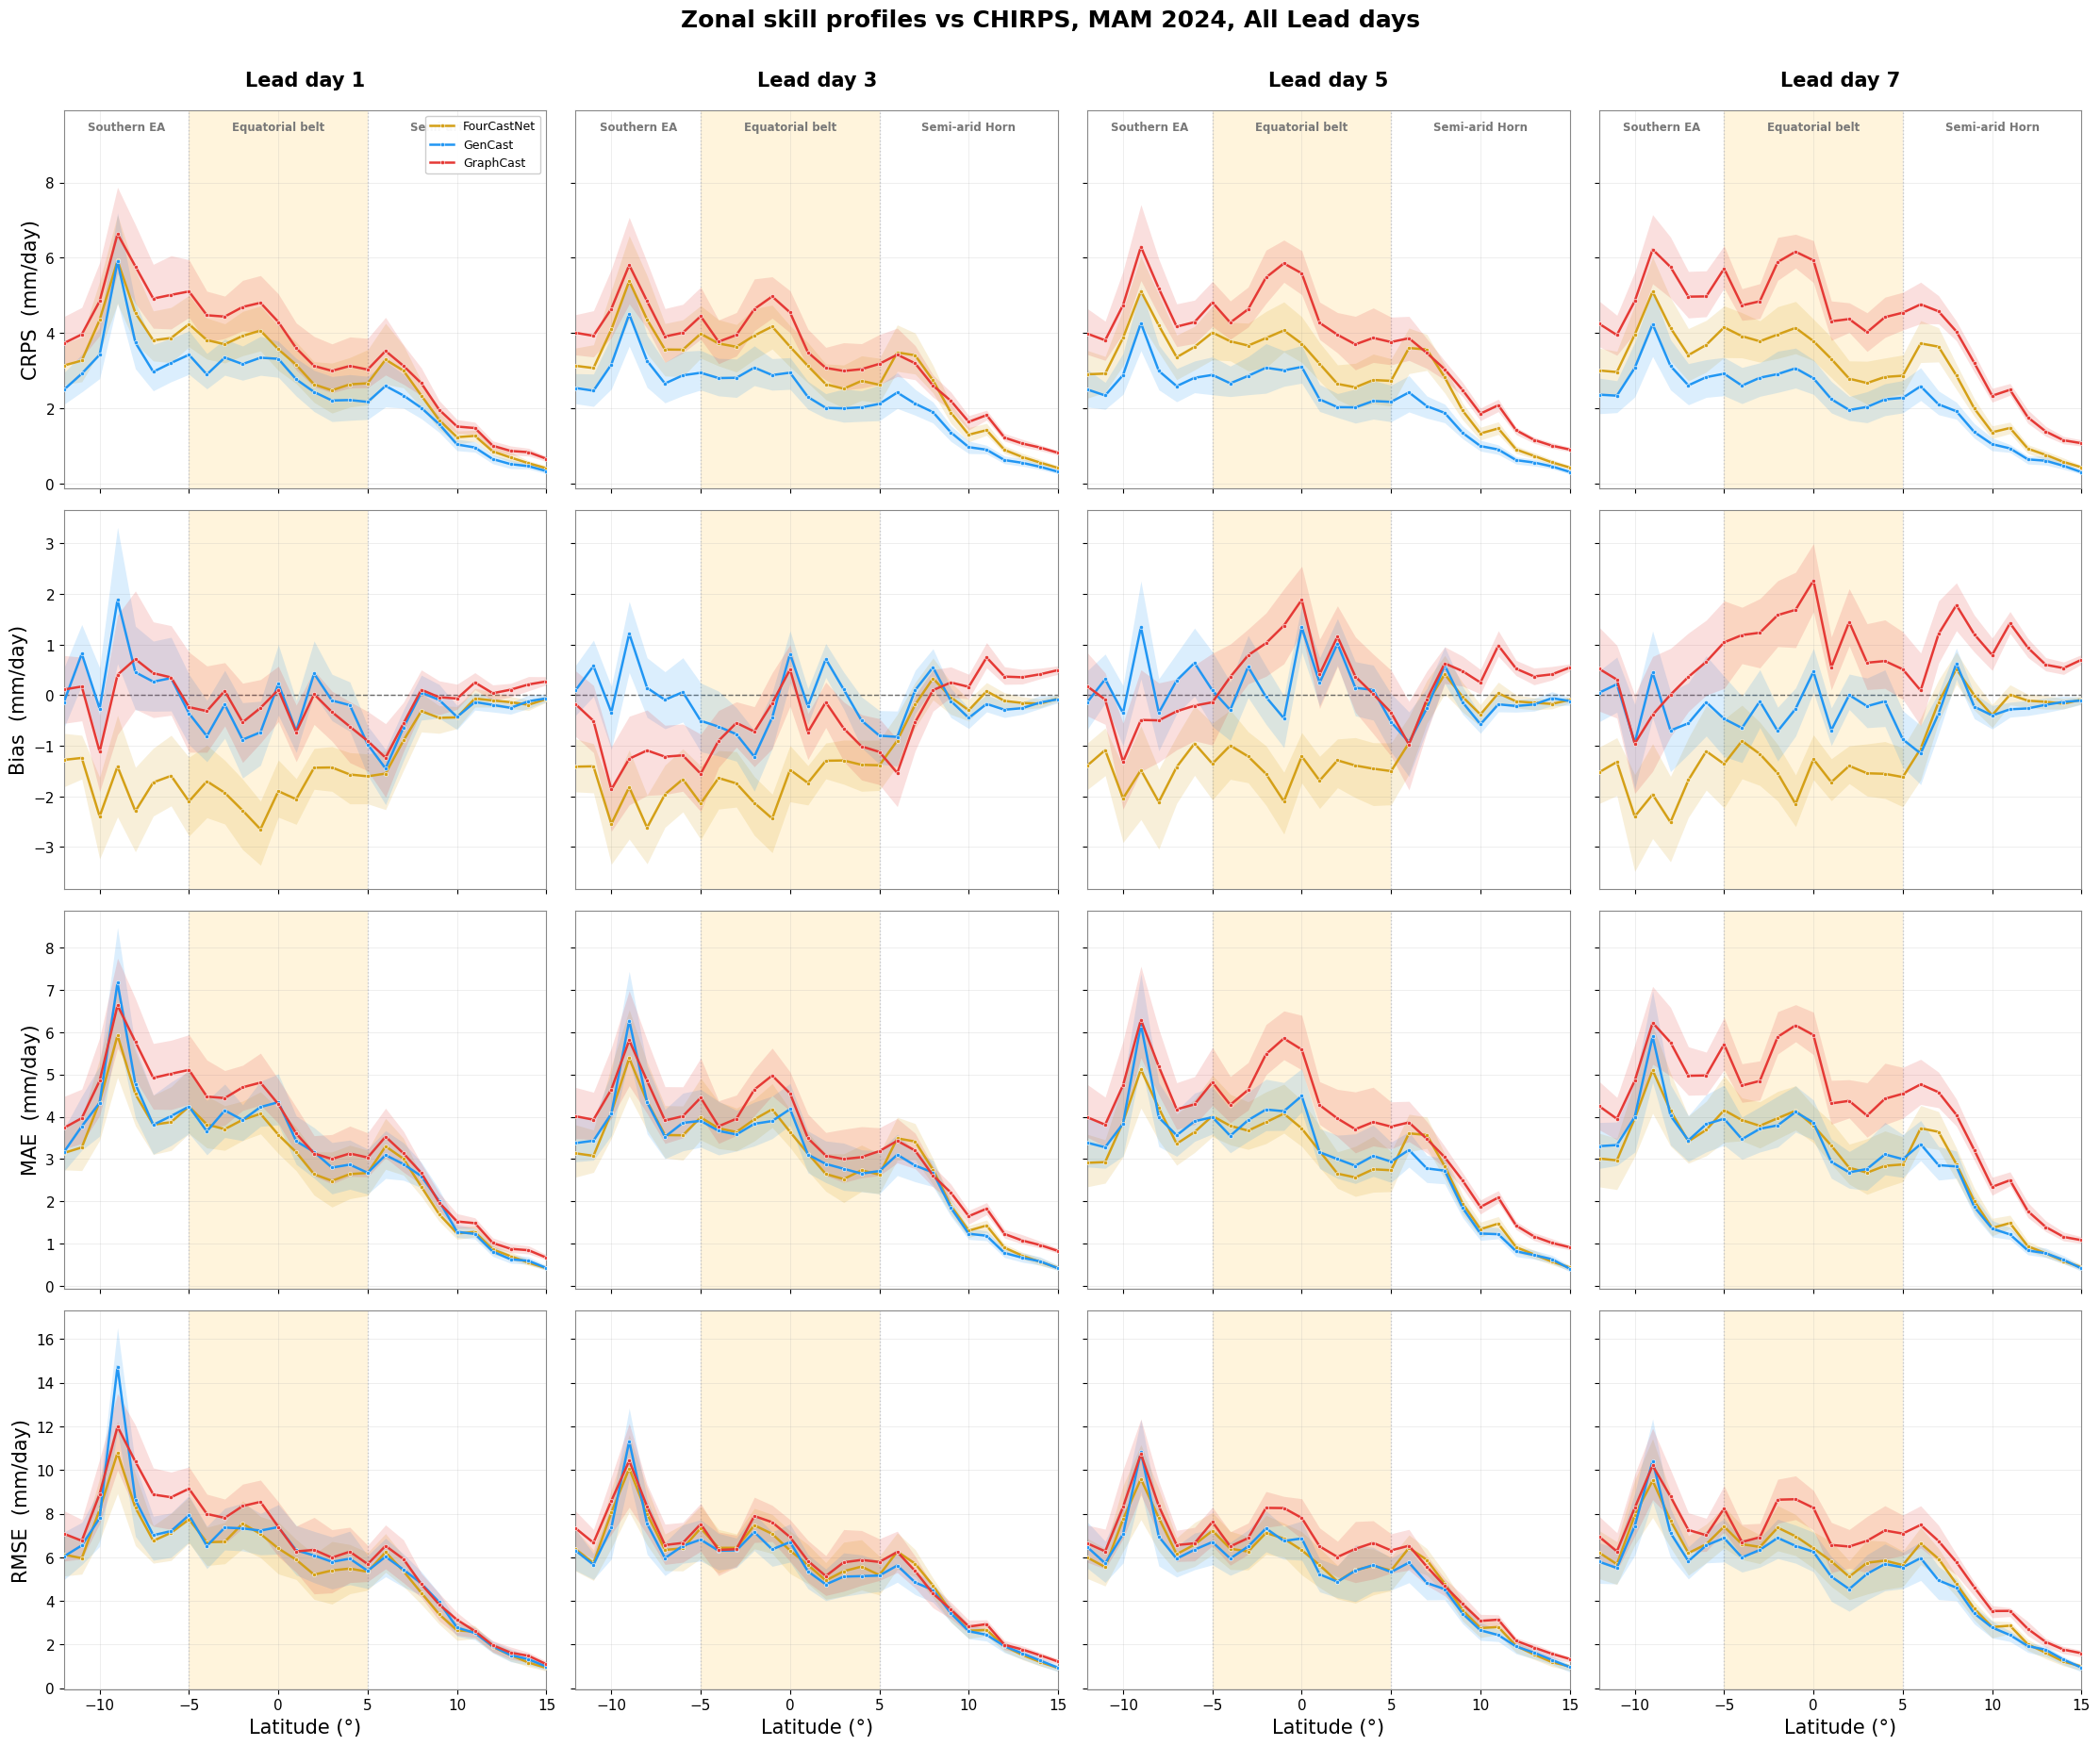

In [27]:
# ── Grid: metric (rows) × lead day (cols), y-scale shared per row ─────────────
nrow, ncol = len(METRICS), len(LEAD_DAYS)
fig, axes = plt.subplots(nrow, ncol, figsize=(5.6 * ncol, 4.6 * nrow),
                         sharex=True, sharey='row')

for r, metric in enumerate(METRICS):
    for c, ld in enumerate(LEAD_DAYS):
        ax = axes[r, c]
        for m in MODELS:
            lo, hi = cis_ld[ld][m][metric]
            ax.fill_between(LAT, lo, hi, color=COLORS[m], alpha=0.16, lw=0, zorder=2)
            ax.plot(LAT, profiles_ld[ld][m][metric].values, color=COLORS[m],
                    lw=1.8, marker='o', ms=3, mec='white', mew=0.4,
                    label=MODEL_LABELS[m], zorder=3)
        if metric == 'Bias':
            ax.axhline(0, color='#333333', ls='--', lw=1, alpha=0.8, zorder=1)
        add_zone_context(ax, label_zones=False)        # shading + boundaries only
        ax.grid(alpha=0.25, lw=0.6)
        ax.set_xlim(LAT.min(), LAT.max())
        if r == 0:
            ax.set_title(f'Lead day {ld}', fontsize=15, fontweight='bold', pad=18)
        if c == 0:
            ax.set_ylabel(f'{metric}  (mm/day)', fontsize=15)
        if r == nrow - 1:
            ax.set_xlabel('Latitude (°)', fontsize=15)

# zone labels on the top row only (sharey='row' → expand headroom once)
ymin, ymax = axes[0, 0].get_ylim()
axes[0, 0].set_ylim(ymin, ymax + 0.20 * (ymax - ymin))
for c in range(ncol):
    for lo_z, hi_z, name in ZONES:
        axes[0, c].text((lo_z + hi_z) / 2, 0.97, name,
                        transform=axes[0, c].get_xaxis_transform(),
                        ha='center', va='top', fontsize=8.5, color='#777777',
                        fontweight='bold')

axes[0, 0].legend(fontsize=9, loc='upper right', framealpha=0.95)
fig.suptitle('Zonal skill profiles vs CHIRPS, MAM 2024, All Lead days',
             fontsize=18, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('mam2024_analysis_outputs/zonal_skill_profiles_all_leads.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Full 2D skill maps, is it really latitude?

The zonal profiles collapse longitude away. Here we keep the full map and plot the
per-cell **CRPS skill score vs a CHIRPS climatology**:

$$\mathrm{CRPSS} = 1 - \frac{\mathrm{CRPS_{model}}}{\mathrm{CRPS_{climatology}}}$$

- **blue (> 0)** model beats climatology · **red (< 0)** worse than climatology
- the **bold black line is the CRPSS = 0 contour** — the skill / no-skill boundary;
  thin grey lines are the ±0.25 / ±0.5 levels (skill "elevation" rings)
- grey cells = hyper-arid (< 0.5 mm/day climatology), where the skill score is
  unstable and uninformative

With coastlines and borders overlaid, the structure can reveal whether skill
follows latitude or actually tracks the **coast / terrain**.

The reference climatology is built in-sample from the MAM CHIRPS distribution
(mild home advantage for climatology) and this is lead day 1 only — see
[crpss_skill_maps.py](crpss_skill_maps.py).

fourcastnet   CRPSS over wet cells  median=-0.200  frac>0=0.09  (n=456)
gencast       CRPSS over wet cells  median=-0.029  frac>0=0.45  (n=456)
graphcast     CRPSS over wet cells  median=-0.444  frac>0=0.01  (n=456)
saved → mam2024_analysis_outputs/crpss_maps_test.png


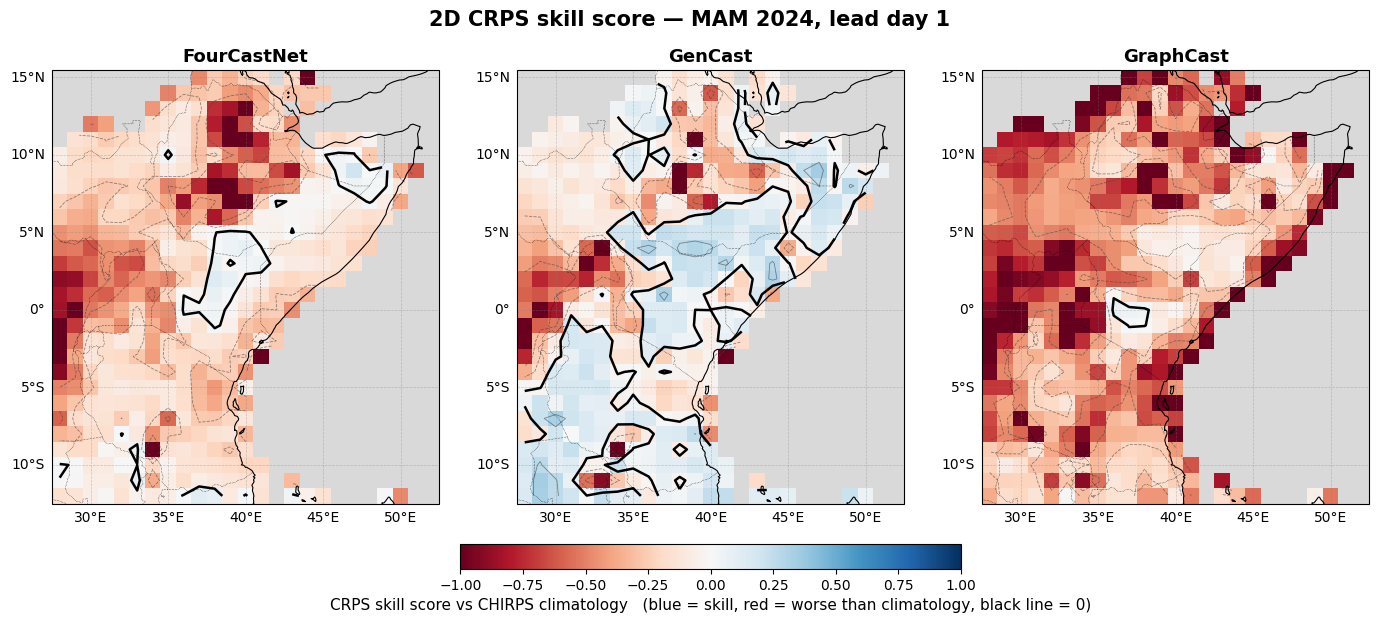

In [ ]:
# Compute + plot the 2D CRPS skill-score maps
%run crpss_skill_maps.py

fourcastnet  median CRPSS  LD1:-0.25  LD3:-0.24  LD5:-0.24  LD7:-0.24
gencast      median CRPSS  LD1:-0.12  LD3:-0.01  LD5:-0.01  LD7:+0.01
graphcast    median CRPSS  LD1:-0.52  LD3:-0.46  LD5:-0.60  LD7:-0.79
saved → mam2024_analysis_outputs/crpss_maps_all_leads_tamsat.png


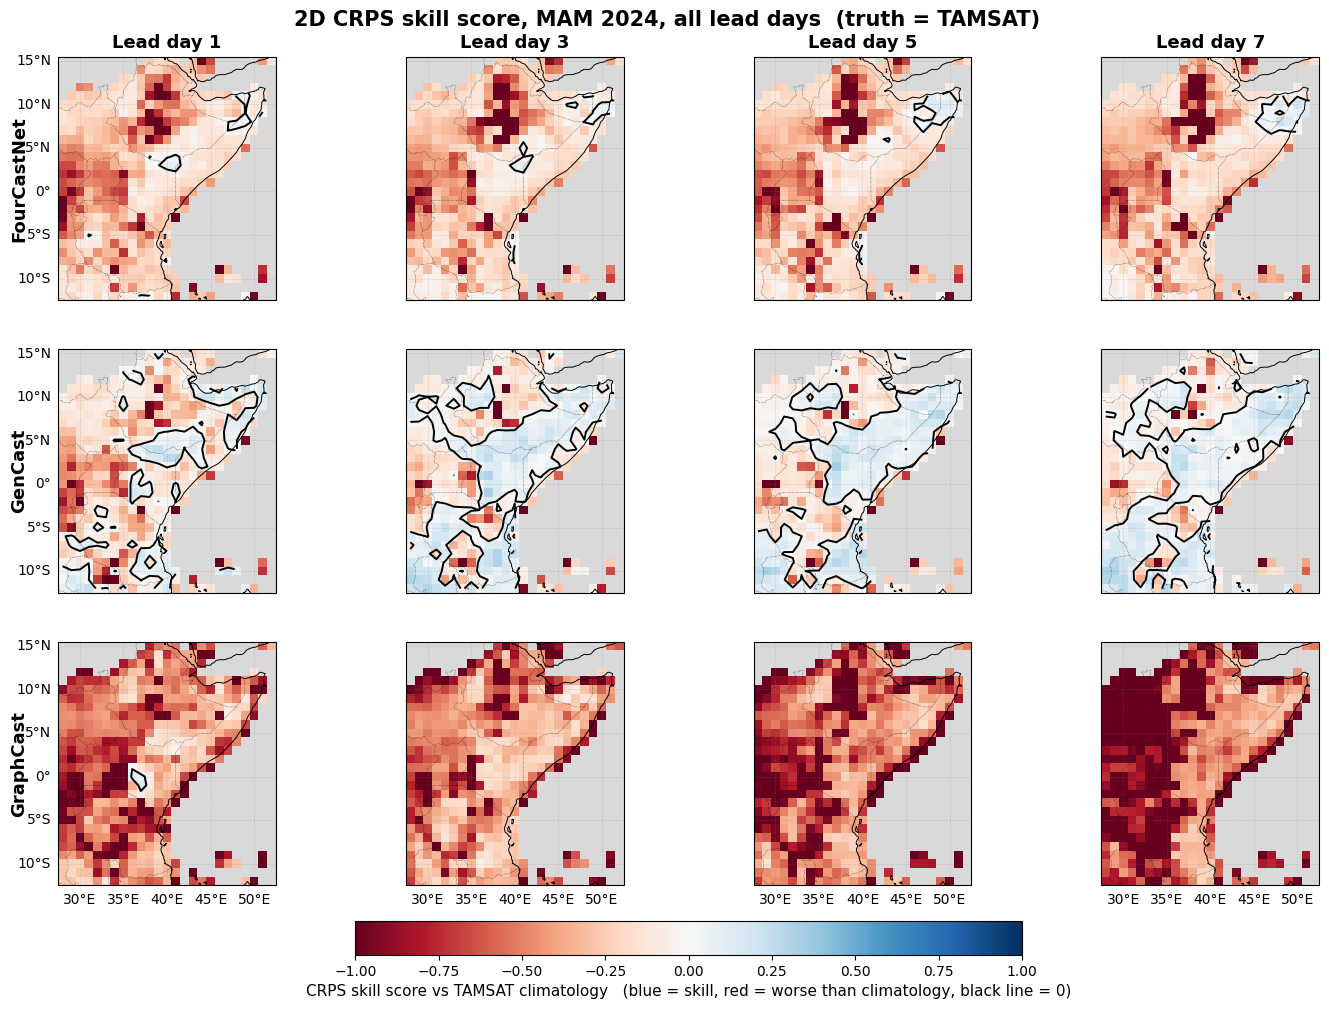

In [2]:
### CRPS skill maps across all lead days
# Grid of models (rows) × lead days (cols). Truth/climatology switchable:

%run crpss_skill_maps_all_leads.py tamsat

fourcastnet  median CRPSS  LD1:-0.20  LD3:-0.20  LD5:-0.21  LD7:-0.22
gencast      median CRPSS  LD1:-0.03  LD3:+0.07  LD5:+0.07  LD7:+0.05
graphcast    median CRPSS  LD1:-0.45  LD3:-0.39  LD5:-0.55  LD7:-0.75
saved → mam2024_analysis_outputs/crpss_maps_all_leads_chirps.png


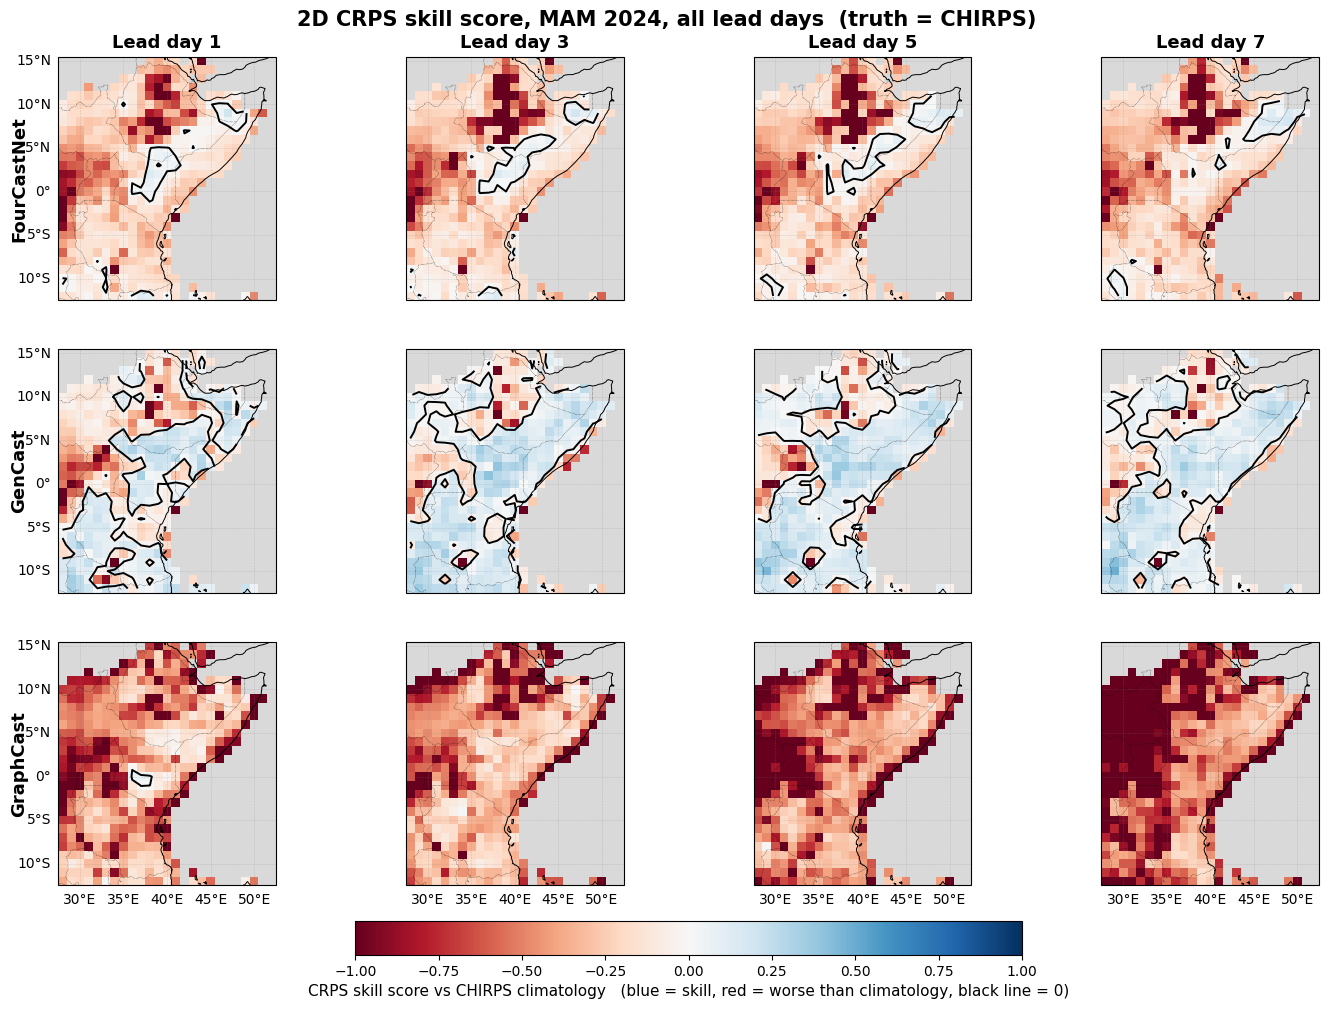

In [4]:
%run crpss_skill_maps_all_leads.py chirps

fourcastnet  ACC  LD1:+0.277  LD3:+0.244  LD5:+0.257  LD7:+0.195
gencast      ACC  LD1:+0.323  LD3:+0.349  LD5:+0.316  LD7:+0.300
graphcast    ACC  LD1:+0.262  LD3:+0.196  LD5:+0.132  LD7:+0.074
saved → mam2024_analysis_outputs/acc_lead_curves_tamsat.png


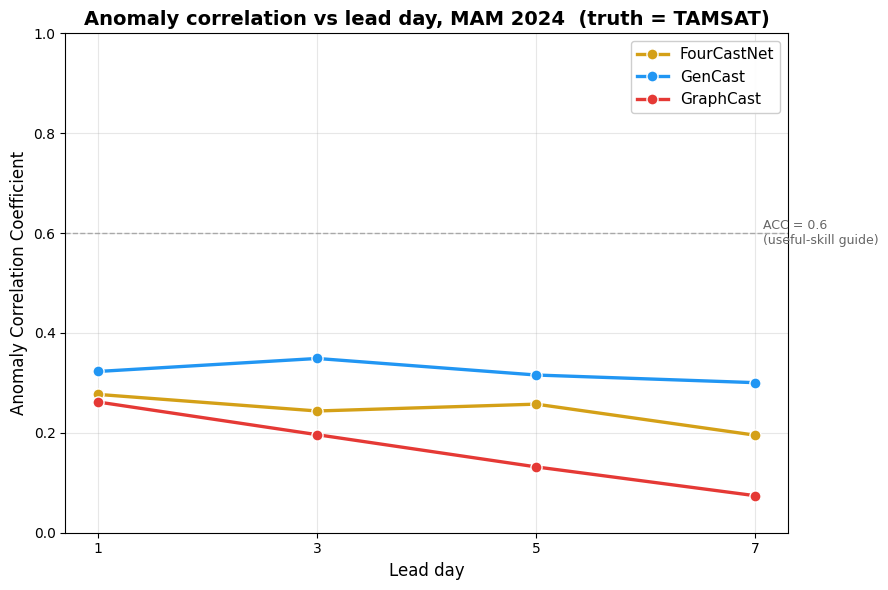

In [3]:
### Anomaly correlation (ACC) vs lead day
# ACC of the 3 models, anomalies w.r.t. the chosen truth's climatology.

%run acc_lead_curves.py tamsat

fourcastnet  ACC  LD1:+0.317  LD3:+0.301  LD5:+0.309  LD7:+0.252
gencast      ACC  LD1:+0.368  LD3:+0.410  LD5:+0.384  LD7:+0.357
graphcast    ACC  LD1:+0.283  LD3:+0.214  LD5:+0.151  LD7:+0.086
saved → mam2024_analysis_outputs/acc_lead_curves_chirps.png


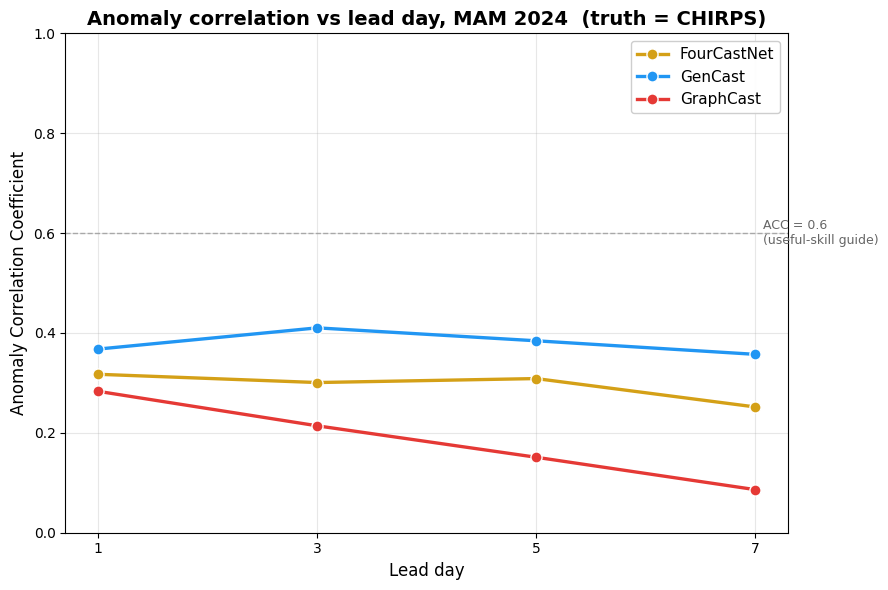

In [5]:
%run acc_lead_curves.py chirps

LD1  spread=3.589  rmse=7.413  SSR=0.484
LD3  spread=4.613  rmse=6.446  SSR=0.716
LD5  spread=5.019  rmse=6.400  SSR=0.784
LD7  spread=4.673  rmse=6.234  SSR=0.750
saved → mam2024_analysis_outputs/ssr_lead_curves_tamsat.png


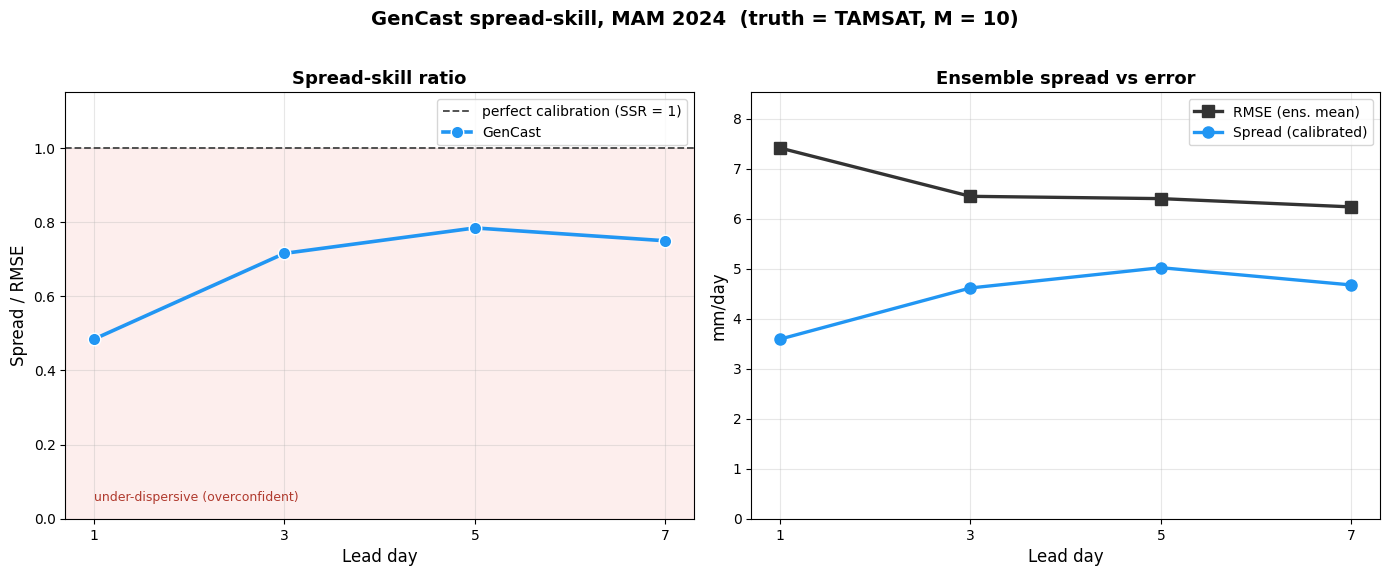

In [6]:
%run ssr_lead_curves.py tamsat

LD1  spread=3.506  rmse=6.809  SSR=0.515
LD3  spread=4.452  rmse=5.869  SSR=0.759
LD5  spread=4.923  rmse=5.845  SSR=0.842
LD7  spread=4.497  rmse=5.755  SSR=0.781
saved → mam2024_analysis_outputs/ssr_lead_curves_chirps.png


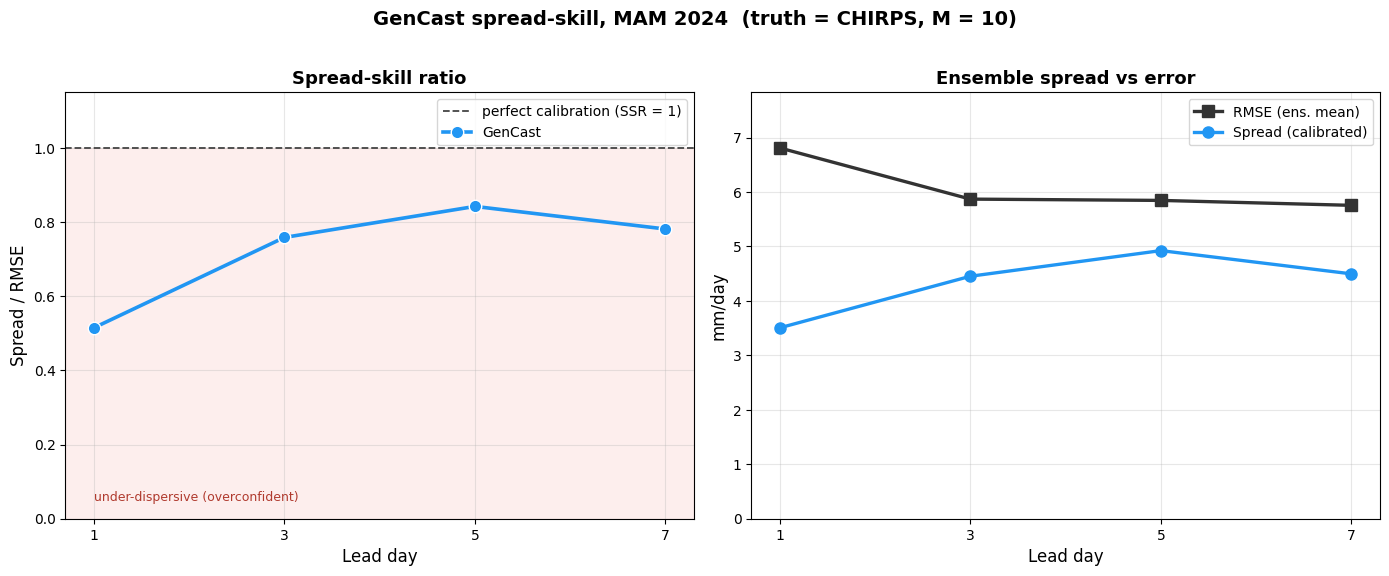

In [9]:
%run ssr_lead_curves.py chirps

LD1  SSR(lat) min=0.31  median=0.51  max=0.65
LD3  SSR(lat) min=0.43  median=0.69  max=0.89
LD5  SSR(lat) min=0.50  median=0.77  max=0.94
LD7  SSR(lat) min=0.52  median=0.74  max=0.98
saved → mam2024_analysis_outputs/ssr_zonal_tamsat.png


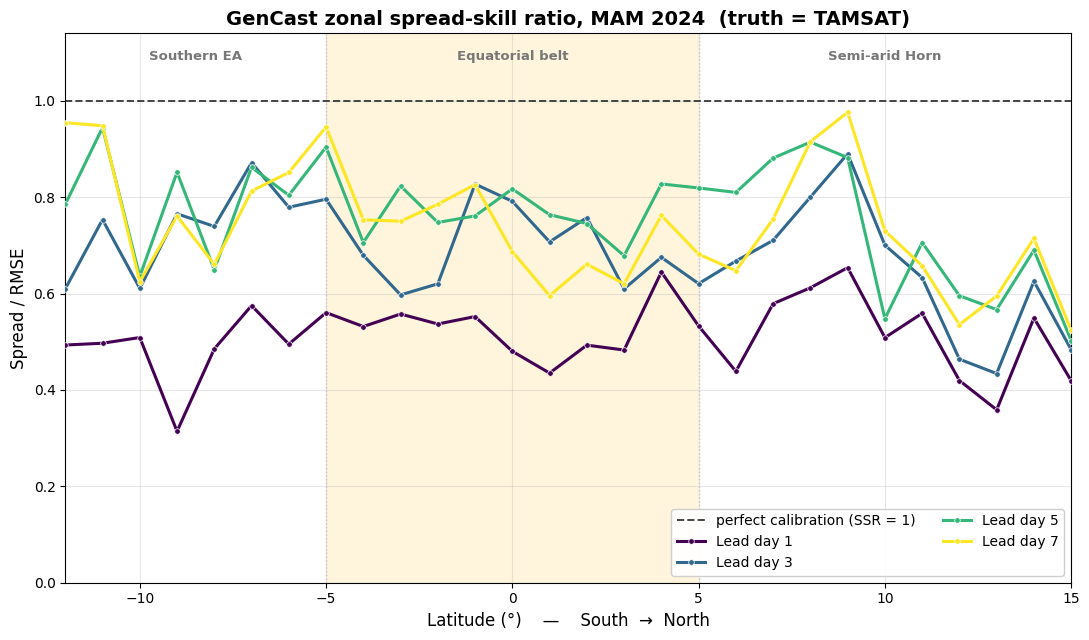

In [7]:
%run ssr_zonal_profile.py tamsat

LD1  SSR(lat) min=0.30  median=0.56  max=0.68
LD3  SSR(lat) min=0.54  median=0.74  max=0.99
LD5  SSR(lat) min=0.61  median=0.82  max=1.05
LD7  SSR(lat) min=0.59  median=0.79  max=1.01
saved → mam2024_analysis_outputs/ssr_zonal_chirps.png


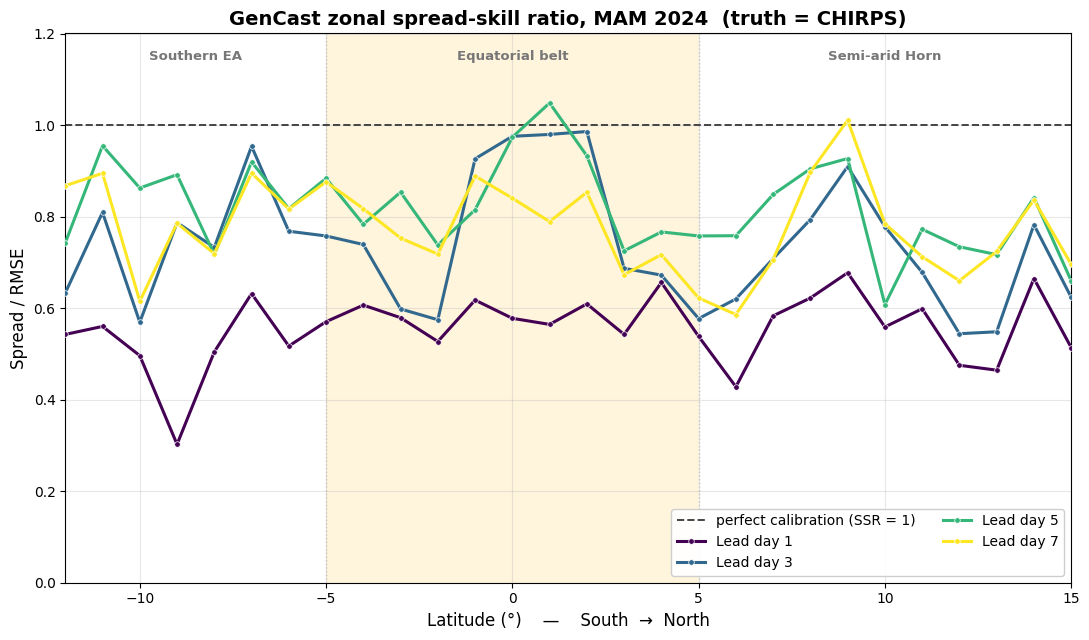

In [8]:
%run ssr_zonal_profile.py chirps